## 2B Crypto Portfolio Risk Calculator (Finance)

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
coins=["BTC-USD","ETH-USD","ADA-USD","SOL-USD","LINK-USD"]
data=yf.download(coins,start="2025-11-24",end="2026-02-22")

C:\Users\Abhinav Shivanadri\AppData\Local\Temp\ipykernel_7116\3899433791.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(coins,start="2025-11-24",end="2026-02-22")
[*********************100%***********************]  5 of 5 completed


In [22]:
data

Price          Close                                                    \
Ticker       ADA-USD       BTC-USD      ETH-USD   LINK-USD     SOL-USD   
Date                                                                     
2025-11-24  0.427842  88270.562500  2952.713379  12.964276  138.371353   
2025-11-25  0.421617  87341.890625  2957.936279  13.065638  138.891144   
2025-11-26  0.435622  90518.367188  3027.812012  13.455601  143.012192   
2025-11-27  0.433685  91285.375000  3014.542236  13.348663  140.846405   
2025-11-28  0.420231  90919.265625  3032.304443  13.139940  137.390198   
...              ...           ...          ...        ...         ...   
2026-02-17  0.280967  67494.218750  1992.194336   8.830567   85.197609   
2026-02-18  0.273586  66425.320312  1953.974121   8.598906   81.566948   
2026-02-19  0.272547  66957.523438  1948.201050   8.569495   82.393250   
2026-02-20  0.284907  68005.421875  1969.022339   8.941406   84.635109   
2026-02-21  0.280022  68003.765625  1973.737183   8.876016   85.211136   

Price           High                                                    ...  \
Ticker       ADA-USD       BTC-USD      ETH-USD   LINK-USD     SOL-USD  ...   
Date                                                                    ...   
2025-11-24  0.433588  89206.335938  2982.822021  13.178526  139.483902  ...   
2025-11-25  0.428621  88457.335938  2978.704346  13.197150  140.346634  ...   
2025-11-26  0.436576  90581.156250  3043.927002  13.492705  144.471039  ...   
2025-11-27  0.438462  91897.578125  3070.731934  13.553444  144.173218  ...   
2025-11-28  0.435241  92969.085938  3095.033203  13.510628  143.304214  ...   
...              ...           ...          ...        ...         ...  ...   
2026-02-17  0.289309  69201.867188  2013.856079   8.980164   87.550171  ...   
2026-02-18  0.286780  68434.429688  2037.158569   8.977254   85.851189  ...   
2026-02-19  0.276747  67277.125000  1985.807617   8.729704   82.574333  ...   
2026-02-20  0.292904  68269.031250  1980.243774   8.992319   85.261917  ...   
2026-02-21  0.285963  68657.703125  1994.827759   9.005772   86.640648  ...   

Price           Open                                                    \
Ticker       ADA-USD       BTC-USD      ETH-USD   LINK-USD     SOL-USD   
Date                                                                     
2025-11-24  0.408558  86798.773438  2801.204346  12.509327  130.706039   
2025-11-25  0.427843  88269.960938  2952.584473  12.964057  138.378891   
2025-11-26  0.421617  87345.585938  2958.329590  13.065667  138.889877   
2025-11-27  0.435622  90517.765625  3027.799072  13.455579  143.012527   
2025-11-28  0.433679  91285.382812  3014.543701  13.348682  140.846481   
...              ...           ...          ...        ...         ...   
2026-02-17  0.285497  68843.093750  1997.921753   8.925531   86.428833   
2026-02-18  0.280966  67488.023438  1992.195068   8.830567   85.196930   
2026-02-19  0.273585  66425.625000  1953.994141   8.598897   81.567055   
2026-02-20  0.272551  66958.578125  1948.268799   8.569484   82.393387   
2026-02-21  0.284907  68000.250000  1968.861816   8.941393   84.635170   

Price          Volume                                                   
Ticker        ADA-USD      BTC-USD      ETH-USD   LINK-USD     SOL-USD  
Date                                                                    
2025-11-24  814509902  74433896110  32491657389  708639149  6046925667  
2025-11-25  652730619  64837343545  23336017779  674660530  4512057787  
2025-11-26  582375709  66496301869  21433162961  535075113  5361639551  
2025-11-27  482157613  57040622845  16972780500  445590223  3419017564  
2025-11-28  624407301  60895830289  20659958964  478723295  4865188881  
...               ...          ...          ...        ...         ...  
2026-02-17  375377238  34866936040  20929890501  548270642  3175385366  
2026-02-18  357622116  33094301643  20187307041  537712409  3282222779  
2026-02-19  3569

In [23]:
log_return=np.log(data["Close"]/data["Close"].shift(1))
log_return.head()

Ticker,ADA-USD,BTC-USD,ETH-USD,LINK-USD,SOL-USD
Date,,,,,
2025-11-24,NaN,NaN,NaN,NaN,NaN
2025-11-25,-0.014657,-0.010576,0.001767,0.007788,0.003749
2025-11-26,0.032678,0.035723,0.023348,0.029410,0.029239
2025-11-27,-0.004456,0.008438,-0.004392,-0.007979,-0.015260
2025-11-28,-0.031514,-0.004019,0.005875,-0.015760,-0.024845


In [24]:
log_return=log_return.dropna()

In [25]:
returns=data["Close"].pct_change().dropna()
mean_returns = returns.mean()

In [26]:
returns

Ticker,ADA-USD,BTC-USD,ETH-USD,LINK-USD,SOL-USD
Date,,,,,
2025-11-25,-0.014550,-0.010521,0.001769,0.007819,0.003756
2025-11-26,0.033217,0.036368,0.023623,0.029846,0.029671
2025-11-27,-0.004447,0.008474,-0.004383,-0.007947,-0.015144
2025-11-28,-0.031022,-0.004011,0.005892,-0.015636,-0.024539
2025-11-29,-0.011537,-0.000743,-0.013395,-0.010427,-0.009524
...,...,...,...,...,...
2026-02-17,-0.015846,-0.019594,-0.002865,-0.010640,-0.014245
2026-02-18,-0.026270,-0.015837,-0.019185,-0.026234,-0.042615
2026-02-19,-0.003798,0.008012,-0.002955,-0.003420,0.010130


In [27]:
mean_returns

Ticker
ADA-USD    -0.003739
BTC-USD    -0.002516
ETH-USD    -0.003789
LINK-USD   -0.003503
SOL-USD    -0.004696
dtype: float64

In [28]:
volatility=returns.std()

In [29]:
volatility

Ticker
ADA-USD     0.045478
BTC-USD     0.028612
ETH-USD     0.038073
LINK-USD    0.038807
SOL-USD     0.038326
dtype: float64

In [11]:
stats=pd.DataFrame({
    "mean return":mean_returns,
    "volatility":volatility
})
stats

,mean return,volatility
Ticker,,
ADA-USD,-0.003739,0.045478
BTC-USD,-0.002516,0.028612
ETH-USD,-0.003789,0.038073
LINK-USD,-0.003503,0.038807
SOL-USD,-0.004696,0.038326


In [12]:
def log_posterior_sigma(sigma,returns):
    if sigma<=0:
        return -np.inf
    n=len(returns)
    sum_sq=np.sum(returns**2)
    log_likelihood=-n*np.log(sigma)-sum_sq/(2*sigma**2)
    return log_likelihood

In [13]:
def metropolis_hastings(returns,interations=10000,prop_width=0.001):
    sigma_curr=np.std(returns)
    samples=[]
    accepted=0
    for i in range (interations):
        sigma_proposal=np.random.normal(sigma_curr,prop_width)
        log_accept_ratio=(log_posterior_sigma(sigma_proposal,returns)-log_posterior_sigma(sigma_curr,returns))
        if np.log(np.random.rand())<log_accept_ratio:
            sigma_curr=sigma_proposal
            accepted+=1
        samples.append(sigma_curr)
    accepted_ratio=accepted/interations
    return np.array(samples),accepted_ratio




In [14]:
results={}
summary=[]
for coin in log_return.columns:
    returns=log_return[coin].values
    samples,acc_ratio=metropolis_hastings(returns)
    burn_in=3000
    posterier=samples[burn_in:]
    mean_sigma=np.mean(posterier)
    ci_lower=np.percentile(posterier,2.5)
    ci_upper=np.percentile(posterier,97.5)
    results[coin]=posterier
    summary.append([coin,mean_sigma,ci_lower,ci_upper])

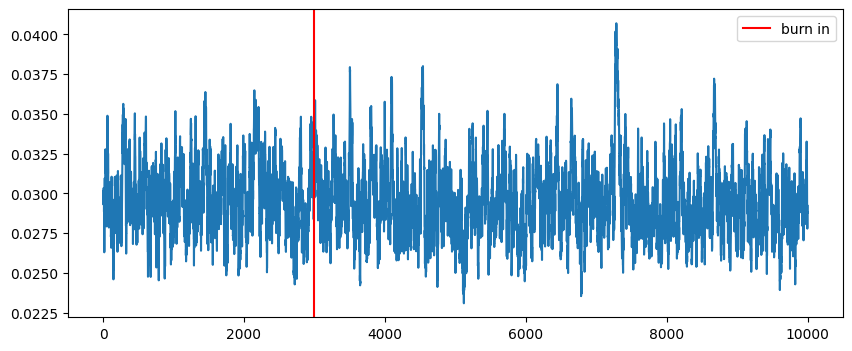

In [15]:
btc_returns=log_return['BTC-USD'].values
btc_samples,_=metropolis_hastings(btc_returns)
plt.figure(figsize=(10,4))
plt.plot(btc_samples)
plt.axvline(3000,label="burn in",color="red")
plt.legend()

In [16]:
vol_table=pd.DataFrame(summary,columns=["coin","posterior mean volatility","lower 95% ci","upper 95 ci"])
vol_table

,coin,posterior mean volatility,lower 95% ci,upper 95 ci
0,ADA-USD,0.045813,0.039529,0.054131
1,BTC-USD,0.029270,0.025151,0.033749
2,ETH-USD,0.039320,0.033805,0.045421
3,LINK-USD,0.039456,0.034160,0.046397
4,SOL-USD,0.040057,0.034303,0.047806


In [17]:
# let us compare historical with the mcmc estimations
comparsion=pd.DataFrame({
    "historical volatility":volatility,
    "bayesian volatility mean":vol_table["posterior mean volatility"].values
})
comparsion

,historical volatility,bayesian volatility mean
Ticker,,
ADA-USD,0.045478,0.045813
BTC-USD,0.028612,0.029270
ETH-USD,0.038073,0.039320
LINK-USD,0.038807,0.039456
SOL-USD,0.038326,0.040057


In [18]:
weights=np.ones(len(coins))/len(coins) #equal weights for all coins
portfolio_vol_samples=[]
num_samples=len(results["BTC-USD"])
for i in range(num_samples):
    sigma_vec=np.array([
        results[coin][i] for coin in coins
    ])
    cov_matrix=np.diag(sigma_vec**2)
    portfolio_var=weights.T@cov_matrix@weights
    portfolio_vol_samples.append(np.sqrt(portfolio_var))
portfolio_vol_samples=np.array(portfolio_vol_samples)

In [19]:
portfolio_mean=np.mean(portfolio_vol_samples)
portfolio_ci=np.percentile(portfolio_vol_samples,[2.5,97.5])
print("volatility mean: ",portfolio_mean)
print("95 % ci: ",portfolio_ci)

volatility mean:  0.017551756147128887
95 % ci:  [0.01626138 0.01881161]


Text(0, 0.5, 'density')

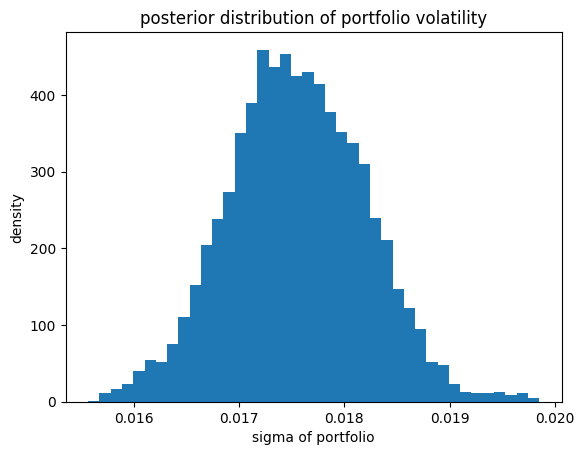

In [20]:
plt.hist(portfolio_vol_samples,bins=40)
plt.title("posterior distribution of portfolio volatility")
plt.xlabel("sigma of portfolio")
plt.ylabel("density")   

In [21]:

vol_table.sort_values("posterior mean volatility",ascending=False)

,coin,posterior mean volatility,lower 95% ci,upper 95 ci
0,ADA-USD,0.045813,0.039529,0.054131
4,SOL-USD,0.040057,0.034303,0.047806
3,LINK-USD,0.039456,0.034160,0.046397
2,ETH-USD,0.039320,0.033805,0.045421
1,BTC-USD,0.029270,0.025151,0.033749


Which coin has high risk?<br>
the coin with the highest posterior mean volatility in the above is the riskiest.From the table we can say that ADA_USD,LINK-USd are high risk coins

# Analysis

I used 90 days of historical price data to estimate daily return volatility.using a longer time improves the stability of volatility estimates compared to short samples.<br><br>The posterior mean volatility values are close to the historical volatilty computed from the data.this indicates that our mcmc sampler is working well.<br><br>the 95 % CI are narrow beacause we have about 90 days data.with more data,the uncertainity around volatilty may decrease.<br><br> amoung the five coins,the coins with the highest posterior mean volatility represents the highest risk asset.from the above table we got to know that ADA,LINK are having higher risk.<br> for equal weight portfolio the overall volatiltiy is lower than the volatiltiy of the riskiest coin,this may lead to diversification and we can reduce our total portfolio risk